In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('world_cup_data.csv')

# Display the first 5 rows to verify correct data loading
print(df.head())

     Country  Year Tournament             Stage  Success Score  \
0  Argentina  2022  World Cup            Winner            100   
1     France  2022  World Cup            Second             80   
2    Croatia  2022  World Cup     Semi Finalist             60   
3    Morocco  2022  World Cup     Semi Finalist             60   
4     Brazil  2022  World Cup  Quarter Finalist             40   

   Domesticity_Index  Market Value (€M)  Average Age  \
0               82.5              900.0         27.9   
1               39.6             1320.0         26.6   
2               61.2              390.0         27.5   
3               84.4              270.0         26.3   
4               86.3             1130.0         27.8   

   Players From Top 5 Leage  Squad Size  Top 5 League Ratio  FIFA Rank  
0                        22          26            0.846154        3.0  
1                        26          26            1.000000        4.0  
2                        14          26        

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
df = pd.read_csv('world_cup_data.csv')

# Preprocessing: Convert Market Value to numeric and fill missing values with 0
df['Market Value (€M)'] = pd.to_numeric(df['Market Value (€M)'], errors='coerce').fillna(0)

# Preprocessing: Fill missing FIFA Ranks with the column mean
df['FIFA Rank'] = pd.to_numeric(df['FIFA Rank'], errors='coerce').fillna(df['FIFA Rank'].mean())

print("Data loaded successfully! Total rows:", len(df))

Data loaded successfully! Total rows: 160


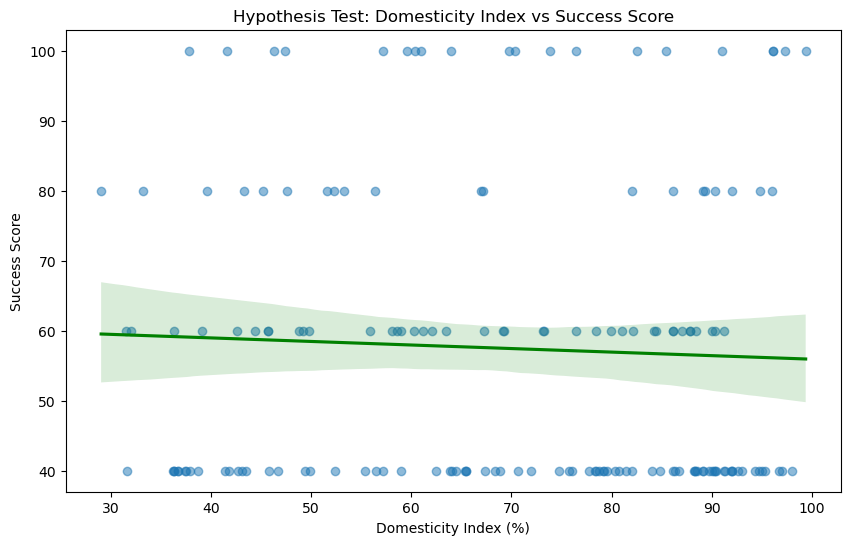

--- Statistical Results for the Proposed Hypothesis ---
Pearson Correlation Coefficient (r): -0.0480
T-test P-value: 0.42201
Conclusion: Failed to reject the null hypothesis. Domesticity Index does not show a statistically significant impact on success.


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the official 160-row data
df = pd.read_csv('world_cup_data.csv')

# 2. Hypothesis Testing: Pearson Correlation
# Goal: Measure the linear relationship between Domesticity and Success
correlation = df['Domesticity_Index'].corr(df['Success Score'])

# 3. Hypothesis Testing: T-Test
# Goal: Compare 'High Domesticity' vs 'Low Domesticity' teams
# We use the mean value as a threshold to split the groups
mean_domesticity = df['Domesticity_Index'].mean()
high_domesticity_group = df[df['Domesticity_Index'] >= mean_domesticity]['Success Score']
low_domesticity_group = df[df['Domesticity_Index'] < mean_domesticity]['Success Score']

t_stat, p_value = stats.ttest_ind(high_domesticity_group, low_domesticity_group)

# 4. Visualization for the Hypothesis (EDA)
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Domesticity_Index', y='Success Score', scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title('Hypothesis Test: Domesticity Index vs Success Score')
plt.xlabel('Domesticity Index (%)')
plt.ylabel('Success Score')
plt.show()

# Print Results
print(f"--- Statistical Results for the Proposed Hypothesis ---")
print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")
print(f"T-test P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: The null hypothesis is rejected. Domesticity Index significantly impacts success.")
else:
    print("Conclusion: Failed to reject the null hypothesis. Domesticity Index does not show a statistically significant impact on success.")

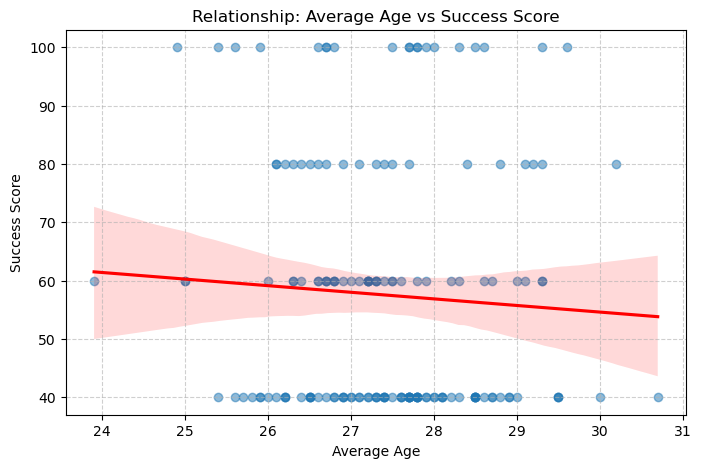

--- Result for Average Age ---
Correlation Coefficient (r): -0.0603
Interpretation: No significant relationship (Very weak correlation).
------------------------------


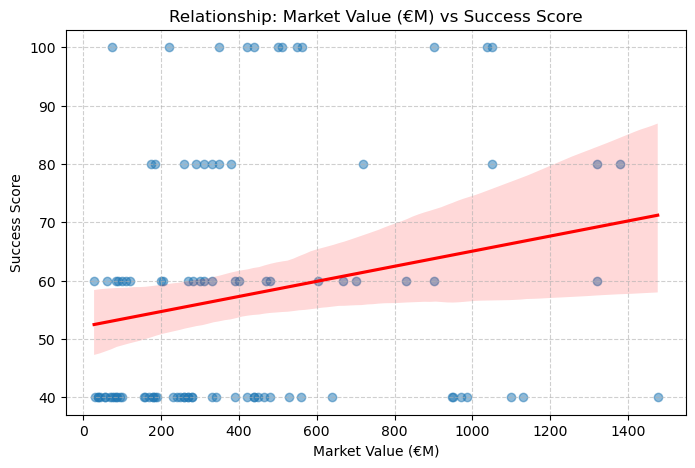

--- Result for Market Value (€M) ---
Correlation Coefficient (r): 0.2140
Interpretation: Positive relationship (As variable increases, success tends to increase).
------------------------------


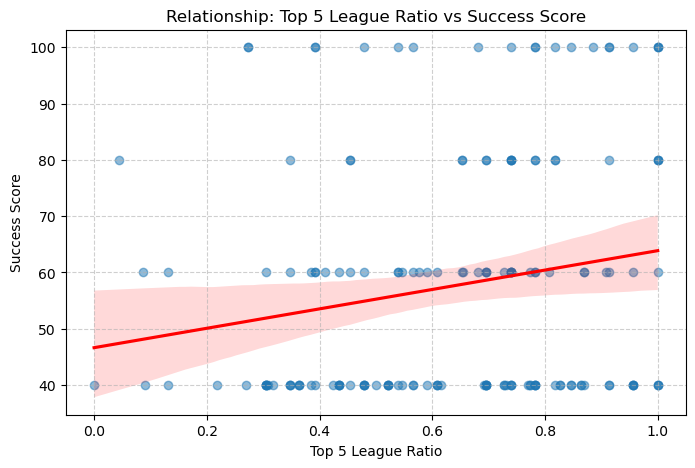

--- Result for Top 5 League Ratio ---
Correlation Coefficient (r): 0.1916
Interpretation: Positive relationship (As variable increases, success tends to increase).
------------------------------


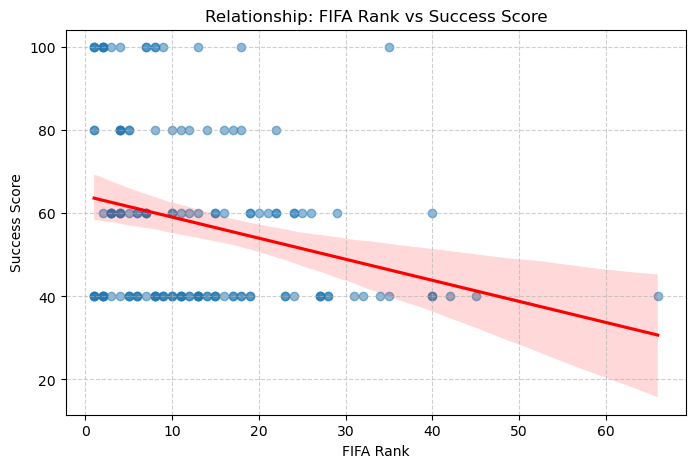

--- Result for FIFA Rank ---
Correlation Coefficient (r): -0.2677
Interpretation: Negative relationship (As variable increases, success tends to decrease).
------------------------------


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the verified 160-row data
df = pd.read_csv('world_cup_data.csv')

# 2. Updated variables list (Removed Domesticity, Added Market Value)
variables = ['Average Age', 'Market Value (€M)', 'Top 5 League Ratio', 'FIFA Rank']

# 3. Generate plots and print results
for var in variables:
    # Preprocessing: Ensure numeric and drop NaNs for current pair
    df[var] = pd.to_numeric(df[var], errors='coerce')
    temp_df = df.dropna(subset=[var, 'Success Score'])
    
    # Calculate Correlation Coefficient (r)
    # (SELECT CORR("Success Score", var) FROM world_cup_data)
    corr_value = temp_df[[var, 'Success Score']].corr().iloc[0, 1]
    
    # Create the Plot
    plt.figure(figsize=(8, 5))
    sns.regplot(data=temp_df, x=var, y='Success Score', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'Relationship: {var} vs Success Score')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    # Print Result Summary
    print(f"--- Result for {var} ---")
    print(f"Correlation Coefficient (r): {corr_value:.4f}")
    if abs(corr_value) < 0.1:
        print("Interpretation: No significant relationship (Very weak correlation).")
    elif corr_value > 0:
        print("Interpretation: Positive relationship (As variable increases, success tends to increase).")
    else:
        print("Interpretation: Negative relationship (As variable increases, success tends to decrease).")
    print("-" * 30)

In [16]:
import pandas as pd

# Load your main data
df = pd.read_csv('world_cup_data.csv')

# Mapping for International Club Trophies (UCL + UEL + Copa Libertadores)
# Format: (Year, Country): Trophy Count
trophy_map = {
    (2024, 'Spain'): 1, (2024, 'Italy'): 1,
    (2022, 'Spain'): 1, (2022, 'Germany'): 1, (2022, 'Brazil'): 1,
    (2020, 'Germany'): 1, (2020, 'Spain'): 1, (2020, 'Brazil'): 1,
    (2018, 'Spain'): 2, (2018, 'Argentina'): 1,
    (2016, 'Spain'): 2, (2016, 'Colombia'): 1,
    (2014, 'Spain'): 2, (2014, 'Argentina'): 1,
    (2012, 'England'): 1, (2012, 'Spain'): 1, (2012, 'Brazil'): 1,
    (2010, 'Italy'): 1, (2010, 'Spain'): 1, (2010, 'Brazil'): 1,
    (2008, 'England'): 1, (2008, 'Russia'): 1,
    (2006, 'Spain'): 2, (2006, 'Brazil'): 1,
    (2004, 'Portugal'): 1, (2004, 'Spain'): 1, (2004, 'Colombia'): 1,
    (2002, 'Spain'): 1, (2002, 'Netherlands'): 1, (2002, 'Paraguay'): 1,
    (2000, 'Spain'): 1, (2000, 'Turkey'): 1, (2000, 'Argentina'): 1,
    (1998, 'Spain'): 1, (1998, 'Italy'): 1, (1998, 'Brazil'): 1,
    (1996, 'Italy'): 1, (1996, 'Germany'): 1, (1996, 'Argentina'): 1,
    (1994, 'Italy'): 2, (1994, 'Argentina'): 1,
    (1992, 'Spain'): 1, (1992, 'Netherlands'): 1, (1992, 'Brazil'): 1,
    (1990, 'Italy'): 2, (1990, 'Paraguay'): 1,
    (1988, 'Netherlands'): 1, (1988, 'Germany'): 1, (1988, 'Uruguay'): 1,
    (1986, 'Romania'): 1, (1986, 'Spain'): 1, (1986, 'Argentina'): 1
}

# Create the new column (default to 0 if no trophy was won)
df['Club_Trophy_Count'] = df.apply(lambda x: trophy_map.get((x['Year'], x['Country']), 0), axis=1)

# Save the updated dataset
df.to_csv('world_cup_data_with_trophies.csv', index=False)
print("New feature 'Club_Trophy_Count' added successfully!")

New feature 'Club_Trophy_Count' added successfully!


C:\Users\Mahir\AppData\Local\Temp\ipykernel_26544\3603592735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Club_Trophy_Count', y='Success Score', palette='viridis')


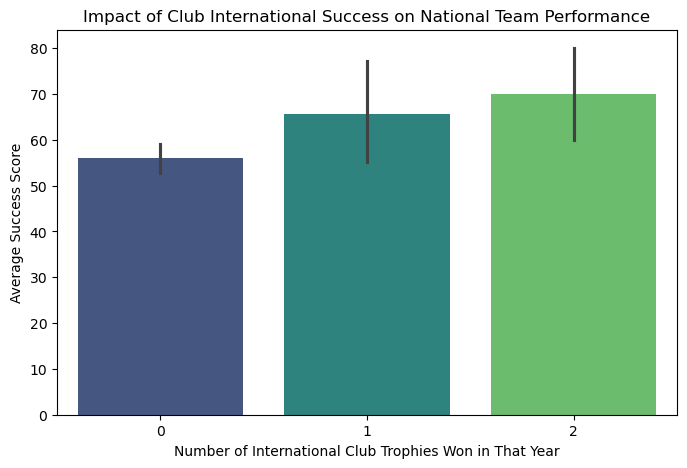

Correlation between Club Trophies and National Success: 0.1667


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the impact of club trophies on national team success
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Club_Trophy_Count', y='Success Score', palette='viridis')
plt.title('Impact of Club International Success on National Team Performance')
plt.xlabel('Number of International Club Trophies Won in That Year')
plt.ylabel('Average Success Score')
plt.show()

# Correlation
new_corr = df['Club_Trophy_Count'].corr(df['Success Score'])
print(f"Correlation between Club Trophies and National Success: {new_corr:.4f}")

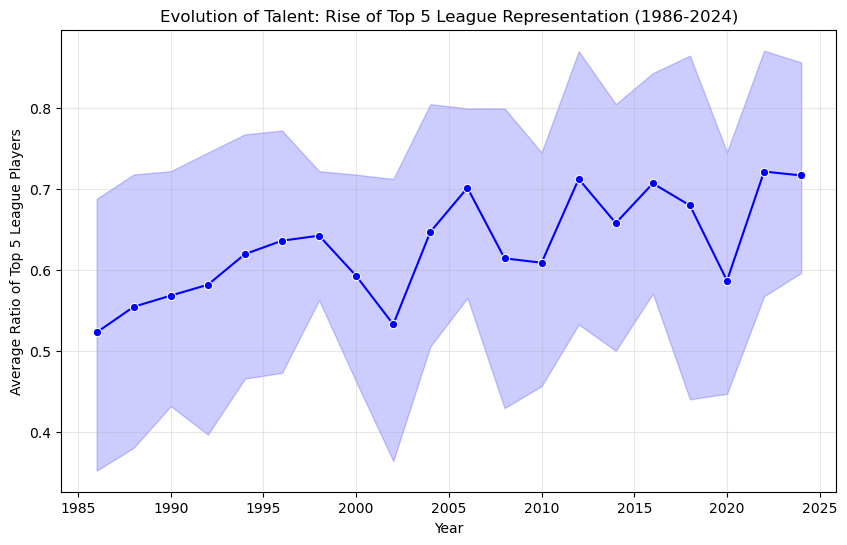

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('world_cup_data.csv')

# Plotting the trend of Top 5 League players over years
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Top 5 League Ratio', marker='o', color='blue')
plt.title('Evolution of Talent: Rise of Top 5 League Representation (1986-2024)')
plt.ylabel('Average Ratio of Top 5 League Players')
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation: 
# "The trend clearly shows that national teams have become increasingly globalized, 
# relying more on players from elite European leagues compared to the 80s and 90s."

C:\Users\Mahir\AppData\Local\Temp\ipykernel_26544\1862753627.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Finalist', y='Domesticity_Index', palette='Set2')


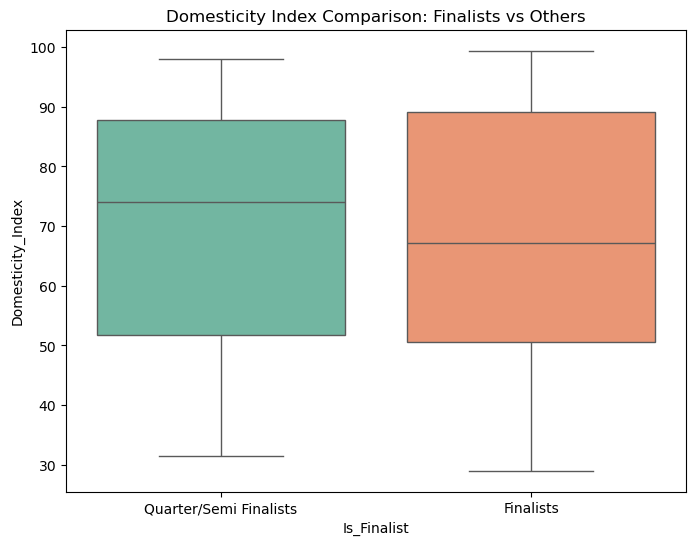

In [ ]:
# Creating a flag for finalists (Winner or Second Place)
df['Is_Finalist'] = df['Success Score'] >= 80

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Is_Finalist', y='Domesticity_Index', palette='Set2')
plt.title('Domesticity Index Comparison: Finalists vs Others')
plt.xticks([0, 1], ['Quarter/Semi Finalists', 'Finalists'])
plt.show()

# Conclusion:
# "The boxplot compares the local player ratio of finalists against teams that were eliminated earlier. 
# If the medians are close, it proves that local player ratio is not a deciding factor for championship."